In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from scipy import linalg
import os

#### I. Import and Prepare Data

Import the dataframe of xDEM generated habitat metrics that we produced in the previous notebook. Then, filter out CCFRP-sampled locations that will not be included in down the road analyses. 

In this instance, I am excluding paired MPA / REF sites that were not sampled 4 of the last 5 years. These sites include: 

- Trinidad (TD)
- Point Conception (PC)
- Laguna Beach (LB)


In [2]:
df = pd.read_csv('habitat_metrics_summary_wide.csv')
df

,Grid_Cell_ID,Full_Area,Area,MPA_Status,aspect_min,aspect_max,aspect_mean,aspect_std,aspect_median,curvature_min,...,terrain_ruggedness_index_min,terrain_ruggedness_index_max,terrain_ruggedness_index_mean,terrain_ruggedness_index_std,terrain_ruggedness_index_median,topographic_position_index_min,topographic_position_index_max,topographic_position_index_mean,topographic_position_index_std,topographic_position_index_median
0,AN01,Ano Nuevo,AN,REF,0.000608,359.999939,189.086755,104.148533,204.255234,-175.711914,...,0.014134,7.820934,0.927034,0.645765,0.776787,-1.815591,2.214877,-0.000039,0.169788,-0.011216
1,AN02,Ano Nuevo,AN,REF,0.000523,359.999756,185.132689,104.709714,200.048111,-158.436584,...,0.040059,8.464078,1.081520,0.635674,0.942224,-1.926841,1.956610,0.000311,0.189826,-0.009952
2,AN03,Ano Nuevo,AN,REF,0.000000,359.999542,189.599869,100.954922,215.612183,-109.372665,...,0.009995,8.280178,0.819195,0.746204,0.587218,-1.462498,1.740995,-0.000016,0.138957,-0.005646
3,AN04,Ano Nuevo,AN,REF,0.000000,359.999725,210.390805,98.236500,236.306763,-199.208252,...,0.000010,12.866380,0.688425,0.912303,0.379040,-2.200926,3.405399,-0.000156,0.160587,-0.001286
4,AN05,Ano Nuevo,AN,REF,0.000000,359.999817,207.752991,95.385900,223.670044,-101.696396,...,0.000000,7.459412,0.763163,0.961316,0.405691,-1.335721,1.534657,0.000054,0.170942,-0.001247
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362,SW15,Swamis,SW,REF,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
363,SW16,Swamis,SW,REF,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
364,SW17,Swamis,SW,REF,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
365,SW18,Swamis,SW,REF,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Remove locations that we will not use in our ultimate analysis from the dataframe. 

In [3]:
disqualified_areas = ['TD', 'PC', 'LB']
df_cleaned = df[~df['Area'].isin(disqualified_areas)]

Distinguish relevant habitat metrics from metadata, and remove instances in habitat data where no habtiat metrics were generated (in this case, due to mistmach between the extent of the DEM and the grid cells during zonal statistics). 

In [4]:
# Select only columns that end with '_mean'
mean_habitat_data = df_cleaned.loc[:, df_cleaned.columns.str.endswith('_mean')]

# Remove rows that have no data in metrics specified by 'habitat_columns'
mean_habitat_data = mean_habitat_data.dropna()

#### II. Perform Principal Component Analysis 
Create a data matrix containing the mean habitat variables, and create a second matrix where each variable has been standardized by computing the z-scores. 

In [5]:
# Print shape
print(mean_habitat_data.shape)
mean_habitat_data

(296, 10)


,aspect_mean,curvature_mean,fractal_roughness_mean,planform_curvature_mean,profile_curvature_mean,roughness_mean,rugosity_mean,slope_mean,terrain_ruggedness_index_mean,topographic_position_index_mean
0,189.086755,-0.002693,2.165833,0.698862,0.701555,0.861623,1.026332,8.597116,0.927034,-0.000039
1,185.132689,0.020764,2.176892,0.768148,0.747384,1.001519,1.032523,10.021022,1.081520,0.000311
2,189.599869,-0.001198,2.216317,0.491474,0.492672,0.796973,1.024742,7.927214,0.819195,-0.000016
3,210.390805,-0.010460,2.194220,0.777225,0.787685,0.648077,1.024913,6.295449,0.688425,-0.000156
4,207.752991,0.003618,2.204904,0.953249,0.949581,0.716227,1.029465,7.032360,0.763163,0.000054
...,...,...,...,...,...,...,...,...,...,...
323,197.147407,0.038223,2.280125,0.536984,0.498412,1.850669,1.102878,17.824768,1.920040,0.000570
324,207.764983,0.043383,2.274368,0.993824,0.950603,1.954676,1.121737,18.469846,2.038654,0.000655
325,219.547903,-0.037620,2.270974,1.154287,1.191865,1.625141,1.099346,15.401662,1.687444,-0.000572
326,224.973616,-0.008709,2.293584,0.854883,0.863673,1.348378,1.078119,12.926812,1.403459,-0.000129


In [6]:
habitat_norm = (mean_habitat_data - np.mean(mean_habitat_data, axis = 0)) / np.std(mean_habitat_data, axis = 0, ddof= 1)
# axis = 0 specifies that means are by column, ddof = 1 specifies that std is unbiased  
np.shape(habitat_norm)

(296, 10)

In [7]:
# sanity check! 
print(np.mean(habitat_norm, axis = 0)) # should be computuationally zero
print(np.std(habitat_norm, axis = 0, ddof = 1)) # should be 1's 

aspect_mean                        8.821772e-16
curvature_mean                     0.000000e+00
fractal_roughness_mean            -2.268456e-15
planform_curvature_mean            4.800964e-17
profile_curvature_mean            -1.440289e-16
roughness_mean                     1.020205e-16
rugosity_mean                      5.899185e-15
slope_mean                        -1.410283e-16
terrain_ruggedness_index_mean      1.500301e-16
topographic_position_index_mean   -9.001808e-18
dtype: float64
aspect_mean                        1.0
curvature_mean                     1.0
fractal_roughness_mean             1.0
planform_curvature_mean            1.0
profile_curvature_mean             1.0
roughness_mean                     1.0
rugosity_mean                      1.0
slope_mean                         1.0
terrain_ruggedness_index_mean      1.0
topographic_position_index_mean    1.0
dtype: float64


Extract the eigenvalues and eigenvectors of the correlation matrix. 

In [8]:
# compute correlation matrix 
R = np.cov(habitat_norm, rowvar = False)
print(R)
print(R.shape)

[[ 1.         -0.2067255  -0.06507901 -0.13874291 -0.13203518 -0.30813216
  -0.16303985 -0.33515981 -0.29915805 -0.20637172]
 [-0.2067255   1.          0.02043082  0.07305098  0.03931785  0.15791495
   0.13148606  0.16752359  0.15741863  0.99930157]
 [-0.06507901  0.02043082  1.         -0.41181043 -0.41321852 -0.25839851
  -0.18395411 -0.24417347 -0.28198151  0.0208783 ]
 [-0.13874291  0.07305098 -0.41181043  1.          0.99942915  0.82800323
   0.8208966   0.81355553  0.83597233  0.06055805]
 [-0.13203518  0.03931785 -0.41321852  0.99942915  1.          0.82426711
   0.81803546  0.80946955  0.83226585  0.02682433]
 [-0.30813216  0.15791495 -0.25839851  0.82800323  0.82426711  1.
   0.94673057  0.99671172  0.99938235  0.1433698 ]
 [-0.16303985  0.13148606 -0.18395411  0.8208966   0.81803546  0.94673057
   1.          0.92130353  0.9464101   0.11329094]
 [-0.33515981  0.16752359 -0.24417347  0.81355553  0.80946955  0.99671172
   0.92130353  1.          0.99538393  0.15410735]
 [-0.299

In [9]:
values, vectors = linalg.eig(R)
values = np.real(values)

Sort the eigenvalues and eigenvectors so that they are arranged in order of decreasing variance (PC1 first, PC2 second, etc.). 

In [10]:
idx = values.argsort()[::-1]   
values_sorted = values[idx]
vectors_sorted = vectors[:,idx]

print(values_sorted)
print(vectors_sorted)

[5.69515366e+00 2.04759926e+00 1.07450245e+00 7.77572747e-01
 3.37339616e-01 6.64610914e-02 6.92446896e-04 5.03178003e-04
 1.75480546e-04 8.08599553e-08]
[[-1.22791568e-01  2.31346733e-01 -6.01138128e-01  7.22984632e-01
   1.56858426e-01  1.50589663e-01  3.46509625e-03 -3.44595637e-03
  -4.62579404e-03  6.09254526e-06]
 [ 8.34590675e-02 -6.67423731e-01 -2.01955381e-01  6.97796861e-02
  -3.12964265e-02 -2.19572635e-02 -1.41644255e-01 -6.70611652e-01
   1.73515676e-01 -2.39291803e-02]
 [-1.48710389e-01 -1.47018814e-01  6.76823414e-01  6.27301709e-01
  -3.02225644e-01  1.08460948e-01  3.87427471e-02 -8.24326607e-03
   4.98785625e-04  5.71502601e-05]
 [ 3.84768487e-01  1.10053916e-01 -1.57731745e-01  9.50545827e-03
  -5.58113547e-01  5.04439170e-02 -2.74644913e-03 -1.35341887e-02
  -4.09384819e-04  7.07563061e-01]
 [ 3.82682871e-01  1.32863161e-01 -1.51116838e-01  7.20367550e-03
  -5.58084718e-01  5.14021240e-02  2.02959615e-03  9.06865129e-03
  -6.63976167e-03 -7.06244881e-01]
 [ 4.092735

Compute and plot the factor loadings.

In [11]:
Lambda = np.diag(values)

A = np.dot(vectors, Lambda**0.5)

In [12]:
percent_variance_PC1 = int(100*(values_sorted[0]/np.sum(values_sorted)))
percent_variance_PC2 = int(100*(values_sorted[1]/np.sum(values_sorted)))

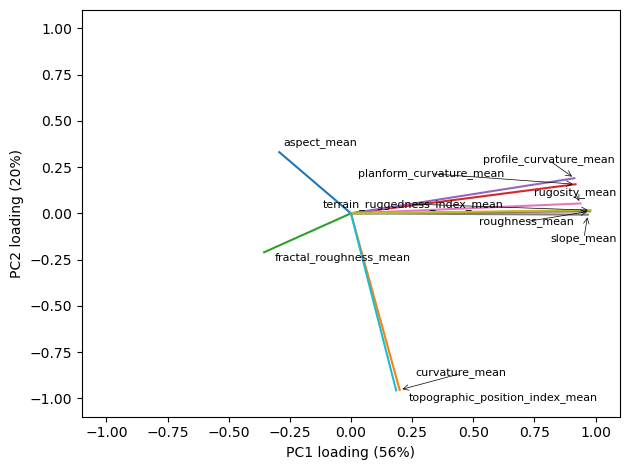

In [16]:
from adjustText import adjust_text

plt.figure()

texts = []

plt.xlim([-1.1, 1.1])
plt.ylim([-1.1, 1.1])

plt.xlabel(f'PC1 loading ({percent_variance_PC1}%)', fontsize=10)
plt.ylabel(f'PC2 loading ({percent_variance_PC2}%)', fontsize=10)

for i, txt in enumerate(mean_habitat_data):
    x, y = A[i, 0], A[i, 1]
    plt.plot([0, x], [0, y], '-')
    texts.append(plt.text(x, y, txt, fontsize=8))

# Now call adjust_text to avoid overlaps with arrows
adjust_text(texts, 
            only_move={'points':'y', 'texts':'xy'},  # move text and points to avoid overlap
            arrowprops=dict(arrowstyle='->', color='black', lw=0.5),
            expand_points=(1.2, 1.4),   # tweak these to control spacing
            expand_text=(1.2, 1.4),
            force_points=0.3,
            force_text=0.3,
            lim=100)

plt.tight_layout()
output_path = f"WSN_Figures/xDEM_metrics_PCA.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.show()
